# Análise Exploratória de Dados — Alfabetização Infantil

Análise exploratória da camada Gold produzida na Fase 2 do Tech Challenge.

O dataset possui informações individuais dos alunos avaliados no 2º ano do Ensino Fundamental, enriquecidas com indicadores e metas de alfabetização em nível municipal.

In [2]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

DATA_PATH = Path("../data/alunos_modelagem.parquet")

df = pd.read_parquet(DATA_PATH)

df.shape

(3867999, 24)

## 1. Estrutura e qualidade dos dados

Nesta etapa são avaliadas a estrutura do dataset, os tipos das variáveis, a presença de valores ausentes e a integridade da chave dos registros.

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3867999 entries, 0 to 3867998
Data columns (total 24 columns):
 #   Column                   Dtype  
---  ------                   -----  
 0   ano                      Int64  
 1   id_municipio             string 
 2   id_municipio_nome        string 
 3   id_escola                string 
 4   id_aluno                 string 
 5   caderno                  str    
 6   serie                    string 
 7   rede                     string 
 8   presenca                 string 
 9   preenchimento_caderno    string 
 10  alfabetizado             string 
 11  proficiencia             float64
 12  peso_aluno               float64
 13  taxa_alfabetizacao       float64
 14  media_portugues          float64
 15  nivel_alfabetizacao      Int64  
 16  percentual_participacao  float64
 17  meta_alfabetizacao_2024  float64
 18  meta_alfabetizacao_2025  float64
 19  meta_alfabetizacao_2026  float64
 20  meta_alfabetizacao_2027  float64
 21  meta_alfabetizacao_

In [5]:
df.head()

,ano,id_municipio,id_municipio_nome,id_escola,id_aluno,caderno,serie,rede,presenca,preenchimento_caderno,...,media_portugues,nivel_alfabetizacao,percentual_participacao,meta_alfabetizacao_2024,meta_alfabetizacao_2025,meta_alfabetizacao_2026,meta_alfabetizacao_2027,meta_alfabetizacao_2028,meta_alfabetizacao_2029,meta_alfabetizacao_2030
0,2023,1100023,Ariquemes,60000062,11000001,10,2° ano do Ensino Fundamental,Municipal,Presente,Prova preenchida,...,757.0999,3,89.79,65.22,68.02,70.71,73.25,75.65,77.9,80.0
1,2023,1100023,Ariquemes,60000062,11000002,10,2° ano do Ensino Fundamental,Municipal,Presente,Prova preenchida,...,757.0999,3,89.79,65.22,68.02,70.71,73.25,75.65,77.9,80.0
2,2023,1100023,Ariquemes,60000062,11000003,10,2° ano do Ensino Fundamental,Municipal,Presente,Prova preenchida,...,757.0999,3,89.79,65.22,68.02,70.71,73.25,75.65,77.9,80.0
3,2023,1100023,Ariquemes,60000062,11000004,10,2° ano do Ensino Fundamental,Municipal,Presente,Prova preenchida,...,757.0999,3,89.79,65.22,68.02,70.71,73.25,75.65,77.9,80.0
4,2023,1100023,Ariquemes,60000062,11000005,10,2° ano do Ensino Fundamental,Municipal,Presente,Prova preenchida,...,757.0999,3,89.79,65.22,68.02,70.71,73.25,75.65,77.9,80.0


### 1.1 Valores ausentes

A completude das variáveis é avaliada pela quantidade e pelo percentual de valores ausentes em cada coluna.

In [6]:
nulos = (
    df.isna()
    .sum()
    .to_frame("quantidade")
)

nulos["percentual"] = (
    nulos["quantidade"] / len(df) * 100
).round(2)

nulos = (
    nulos[nulos["quantidade"] > 0]
    .sort_values("percentual", ascending=False)
)

nulos

,quantidade,percentual
meta_alfabetizacao_2024,559165,14.46
percentual_participacao,534671,13.82
nivel_alfabetizacao,534671,13.82
meta_alfabetizacao_2026,519049,13.42
meta_alfabetizacao_2025,519049,13.42
meta_alfabetizacao_2027,519049,13.42
meta_alfabetizacao_2028,519049,13.42
meta_alfabetizacao_2029,519049,13.42
meta_alfabetizacao_2030,519049,13.42
peso_aluno,513338,13.27


### 1.2 Integridade dos registros

A combinação de ano e identificador do aluno é verificada como chave candidata para identificar possíveis duplicidades no dataset.

In [7]:
duplicados = df.duplicated(
    subset=["ano", "id_aluno"]
).sum()

duplicados

np.int64(0)

## 2. Caracterização da população

Nesta etapa é analisada a composição da população disponível para modelagem, considerando período, série, rede de ensino e situação de participação na avaliação.

In [8]:
distribuicao_ano = (
    df["ano"]
    .value_counts()
    .sort_index()
    .to_frame("quantidade")
)

distribuicao_ano["percentual"] = (
    distribuicao_ano["quantidade"] / len(df) * 100
).round(2)

distribuicao_ano

,quantidade,percentual
ano,,
2023,1747439,45.18
2024,2120560,54.82


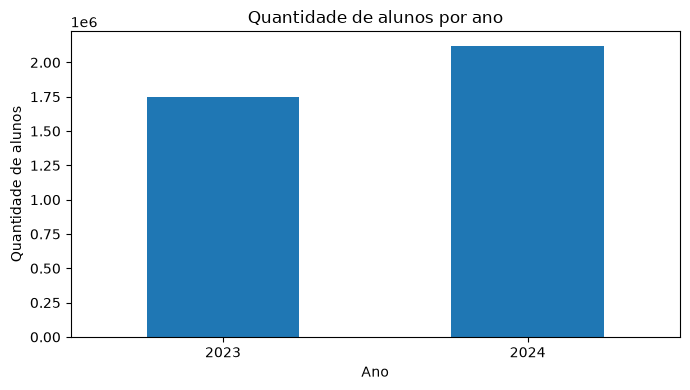

In [9]:
ax = distribuicao_ano["quantidade"].plot(
    kind="bar",
    figsize=(7, 4)
)

ax.set_title("Quantidade de alunos por ano")
ax.set_xlabel("Ano")
ax.set_ylabel("Quantidade de alunos")

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [10]:
df["serie"].value_counts(dropna=False)

serie
2° ano do Ensino Fundamental    3867999
Name: count, dtype: int64[pyarrow]

In [11]:
distribuicao_rede = (
    df["rede"]
    .value_counts(dropna=False)
    .to_frame("quantidade")
)

distribuicao_rede["percentual"] = (
    distribuicao_rede["quantidade"] / len(df) * 100
).round(4)

distribuicao_rede

,quantidade,percentual
rede,,
Municipal,3432576,88.7429
Estadual,435398,11.2564
Privada,25,0.0006


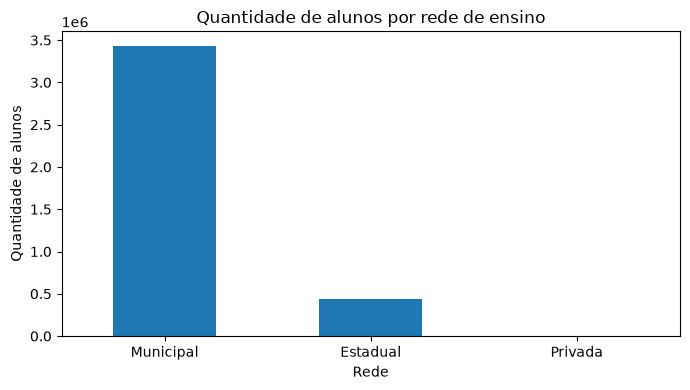

In [12]:
ax = distribuicao_rede["quantidade"].plot(
    kind="bar",
    figsize=(7, 4)
)

ax.set_title("Quantidade de alunos por rede de ensino")
ax.set_xlabel("Rede")
ax.set_ylabel("Quantidade de alunos")

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [13]:
pd.crosstab(
    df["presenca"],
    df["preenchimento_caderno"],
    margins=True
)

preenchimento_caderno,Prova não preenchida,Prova preenchida,All
presenca,,,
Ausente,512153,0,512153
Presente,1185,3354661,3355846
All,513338,3354661,3867999


In [14]:
for coluna in ["presenca", "preenchimento_caderno"]:
    print(f"\n{coluna.upper()}")
    
    resultado = pd.DataFrame({
        "quantidade": df[coluna].value_counts(dropna=False),
        "percentual": (
            df[coluna].value_counts(
                normalize=True,
                dropna=False
            ) * 100
        ).round(2)
    })
    
    display(resultado)


PRESENCA


,quantidade,percentual
presenca,,
Presente,3355846,86.76
Ausente,512153,13.24



PREENCHIMENTO_CADERNO


,quantidade,percentual
preenchimento_caderno,,
Prova preenchida,3354661,86.73
Prova não preenchida,513338,13.27


## 3. Análise da variável-alvo

A variável `alfabetizado` representa a classificação utilizada como candidato a target do problema supervisionado. Nesta etapa são avaliados sua distribuição e seu comportamento entre diferentes grupos da população.

In [15]:
target = (
    df["alfabetizado"]
    .value_counts(dropna=False)
    .to_frame("quantidade")
)

target["percentual"] = (
    target["quantidade"] / len(df) * 100
).round(2)

target

,quantidade,percentual
alfabetizado,,
Sim,1984546,51.31
Não,1883453,48.69


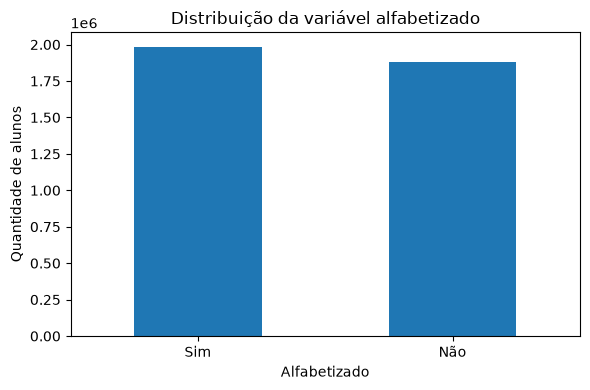

In [16]:
ax = target["quantidade"].plot(
    kind="bar",
    figsize=(6, 4)
)

ax.set_title("Distribuição da variável alfabetizado")
ax.set_xlabel("Alfabetizado")
ax.set_ylabel("Quantidade de alunos")

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### 3.1 Alfabetização por ano

A distribuição da variável-alvo é comparada entre os anos disponíveis para identificar alterações no percentual de alunos classificados como alfabetizados.

In [17]:
target_ano = pd.crosstab(
    df["ano"],
    df["alfabetizado"],
    normalize="index"
) * 100

target_ano.round(2)

alfabetizado,Não,Sim
ano,,
2023,49.79,50.21
2024,47.79,52.21


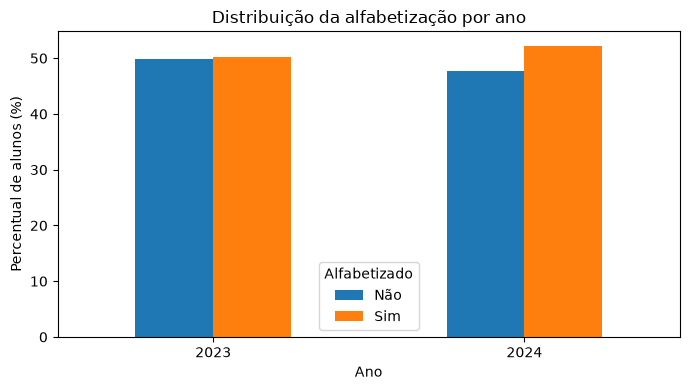

In [18]:
ax = target_ano.plot(
    kind="bar",
    figsize=(7, 4)
)

ax.set_title("Distribuição da alfabetização por ano")
ax.set_xlabel("Ano")
ax.set_ylabel("Percentual de alunos (%)")

plt.xticks(rotation=0)
plt.legend(title="Alfabetizado")
plt.tight_layout()
plt.show()

### 3.2 Alfabetização por rede de ensino

A proporção de alunos classificados como alfabetizados é analisada segundo a rede de ensino.

In [20]:
target_rede = pd.crosstab(
    df["rede"],
    df["alfabetizado"],
    normalize="index"
) * 100

target_rede.round(2)

alfabetizado,Não,Sim
rede,,
Estadual,46.85,53.15
Municipal,48.93,51.07
Privada,36.00,64.00


### 3.3 Relação entre presença e alfabetização

A relação entre participação na avaliação e a variável-alvo é analisada para verificar como alunos ausentes são classificados no dataset.

In [21]:
pd.crosstab(
    df["presenca"],
    df["alfabetizado"],
    margins=True
)

alfabetizado,Não,Sim,All
presenca,,,
Ausente,512153,0,512153
Presente,1371300,1984546,3355846
All,1883453,1984546,3867999


In [22]:
presenca_target = pd.crosstab(
    df["presenca"],
    df["alfabetizado"],
    normalize="index"
) * 100

presenca_target.round(2)

alfabetizado,Não,Sim
presenca,,
Ausente,100.00,0.00
Presente,40.86,59.14


### 3.4 Relação entre preenchimento da prova e alfabetização

É avaliada a classificação dos alunos segundo o preenchimento do caderno de prova.

In [23]:
pd.crosstab(
    df["preenchimento_caderno"],
    df["alfabetizado"],
    margins=True
)

alfabetizado,Não,Sim,All
preenchimento_caderno,,,
Prova não preenchida,513338,0,513338
Prova preenchida,1370115,1984546,3354661
All,1883453,1984546,3867999


In [24]:
preenchimento_target = pd.crosstab(
    df["preenchimento_caderno"],
    df["alfabetizado"],
    normalize="index"
) * 100

preenchimento_target.round(2)

alfabetizado,Não,Sim
preenchimento_caderno,,
Prova não preenchida,100.00,0.00
Prova preenchida,40.84,59.16


### 3.5 População com resultado de avaliação

Considerando que a classificação de alfabetização está associada ao desempenho na avaliação, é analisada separadamente a população que possui resultado de proficiência disponível.

In [25]:
populacao_avaliacao = pd.DataFrame({
    "quantidade": [
        len(df),
        df["proficiencia"].notna().sum(),
        df["proficiencia"].isna().sum(),
    ]
}, index=[
    "Total",
    "Com proficiência",
    "Sem proficiência",
])

populacao_avaliacao["percentual"] = (
    populacao_avaliacao["quantidade"] / len(df) * 100
).round(2)

populacao_avaliacao

,quantidade,percentual
Total,3867999,100.00
Com proficiência,3354661,86.73
Sem proficiência,513338,13.27


## 4. Proficiência e investigação de data leakage

A proficiência representa o desempenho obtido pelo aluno na avaliação. Como a variável-alvo `alfabetizado` está relacionada ao resultado dessa avaliação, é necessário investigar a relação entre ambas antes de considerar a proficiência como variável preditora.

In [26]:
df["proficiencia"].describe()

count    3.354661e+06
mean     7.483799e+02
std      4.758598e+01
min      5.784600e+02
25%      7.197686e+02
50%      7.531500e+02
75%      7.796500e+02
max      9.043820e+02
Name: proficiencia, dtype: float64

In [27]:
proficiencia_target = (
    df.groupby("alfabetizado")["proficiencia"]
    .describe()
)

proficiencia_target

,count,mean,std,min,25%,50%,75%,max
alfabetizado,,,,,,,,
Não,1370115.0,702.815497,31.255528,578.46,681.824417,709.522218,729.443616,742.999819
Sim,1984546.0,779.837129,27.026391,743.00,758.968619,774.333107,794.690000,904.382031


In [28]:
df.groupby("alfabetizado")["proficiencia"].agg(
    quantidade="count",
    minimo="min",
    maximo="max",
    media="mean",
    mediana="median",
)

,quantidade,minimo,maximo,media,mediana
alfabetizado,,,,,
Não,1370115,578.46,742.999819,702.815497,709.522218
Sim,1984546,743.00,904.382031,779.837129,774.333107


In [29]:
avaliados = df["proficiencia"].notna()

regra_743 = (
    (df.loc[avaliados, "proficiencia"] >= 743)
    == 
    (df.loc[avaliados, "alfabetizado"] == "Sim")
)

pd.Series({
    "registros_avaliados": regra_743.size,
    "registros_compativeis": regra_743.sum(),
    "registros_divergentes": (~regra_743).sum(),
    "compatibilidade_pct": regra_743.mean() * 100,
})

registros_avaliados      3354661.0
registros_compativeis    3354661.0
registros_divergentes          0.0
compatibilidade_pct          100.0
dtype: float64

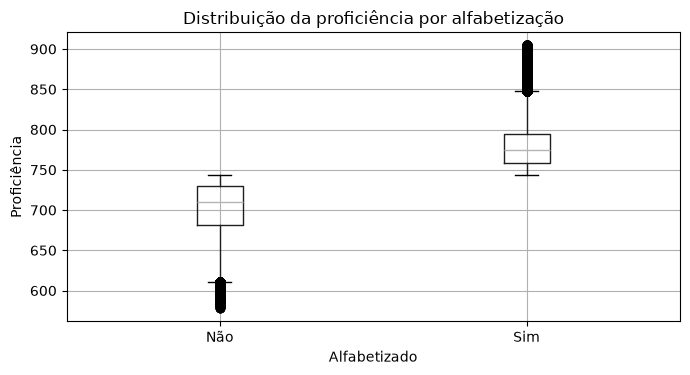

In [30]:
ax = df.loc[avaliados].boxplot(
    column="proficiencia",
    by="alfabetizado",
    figsize=(7, 4)
)

ax.set_title("Distribuição da proficiência por alfabetização")
ax.set_xlabel("Alfabetizado")
ax.set_ylabel("Proficiência")

plt.suptitle("")
plt.tight_layout()
plt.show()

**Achado:** A classificação da variável `alfabetizado` apresenta compatibilidade de 100% com o ponto de corte de 743 na variável `proficiencia` entre os alunos com resultado disponível. Portanto, `proficiencia` contém diretamente a informação utilizada para determinar o target e não deve ser utilizada como variável preditora do modelo.

### 4.1 Indicadores agregados do mesmo ciclo avaliativo

Os indicadores municipais presentes na Gold são analisados quanto à sua relação com a variável-alvo e à sua temporalidade. Indicadores calculados a partir da mesma avaliação utilizada para definir o target podem introduzir informação do próprio período que se pretende prever.

In [31]:
indicadores_municipais = [
    "taxa_alfabetizacao",
    "media_portugues",
    "nivel_alfabetizacao",
    "percentual_participacao",
]

df.groupby(
    ["ano", "id_municipio", "rede"]
)[indicadores_municipais].nunique(dropna=False).describe()

,taxa_alfabetizacao,media_portugues,nivel_alfabetizacao,percentual_participacao
count,12431.0,12431.0,12431.0,12431.0
mean,1.0,1.0,1.0,1.0
std,0.0,0.0,0.0,0.0
min,1.0,1.0,1.0,1.0
25%,1.0,1.0,1.0,1.0
50%,1.0,1.0,1.0,1.0
75%,1.0,1.0,1.0,1.0
max,1.0,1.0,1.0,1.0


In [32]:
taxa_calculada = (
    df.groupby(
        ["ano", "id_municipio", "rede"],
        observed=True
    )
    .agg(
        alunos=("id_aluno", "size"),
        alfabetizados=("alfabetizado", lambda x: (x == "Sim").sum()),
        taxa_gold=("taxa_alfabetizacao", "first"),
    )
    .reset_index()
)

taxa_calculada["taxa_target"] = (
    taxa_calculada["alfabetizados"]
    / taxa_calculada["alunos"]
    * 100
)

taxa_calculada[
    ["taxa_gold", "taxa_target"]
].corr()

,taxa_gold,taxa_target
taxa_gold,1.000000,0.966746
taxa_target,0.966746,1.000000


**Achado:** Os indicadores municipais são constantes dentro de cada combinação de ano, município e rede, confirmando sua natureza agregada. A `taxa_alfabetizacao` apresenta correlação de aproximadamente 0,967 com a proporção de alunos classificados como alfabetizados no mesmo grupo e período. Por representar resultado agregado do mesmo ciclo avaliativo, sua utilização contemporânea como feature apresenta risco de data leakage. O uso de valores históricos será avaliado posteriormente.

In [33]:
correlacoes = df[
    [
        "taxa_alfabetizacao",
        "media_portugues",
        "nivel_alfabetizacao",
        "percentual_participacao",
    ]
].corr()

correlacoes.round(3)

,taxa_alfabetizacao,media_portugues,nivel_alfabetizacao,percentual_participacao
taxa_alfabetizacao,1.000,0.934,0.971,0.379
media_portugues,0.934,1.000,0.882,0.458
nivel_alfabetizacao,0.971,0.882,1.000,0.370
percentual_participacao,0.379,0.458,0.370,1.000


In [34]:
df.groupby(
    "nivel_alfabetizacao",
    dropna=False
)["taxa_alfabetizacao"].agg(
    quantidade="count",
    minimo="min",
    maximo="max",
    media="mean",
)

,quantidade,minimo,maximo,media
nivel_alfabetizacao,,,,
0,471881,4.35,40.00,33.321256
1,561837,40.00,50.00,45.714476
2,822346,50.00,91.67,54.931891
3,711491,60.00,70.00,65.091135
4,444438,70.00,80.00,74.425114
5,321335,80.00,100.00,88.144701
<NA>,530472,2.12,100.00,58.540623


**Achado:** `nivel_alfabetizacao` apresenta faixas claramente delimitadas pela `taxa_alfabetizacao`, indicando que representa uma categorização do desempenho agregado do município. Além disso, `taxa_alfabetizacao`, `media_portugues` e `nivel_alfabetizacao` apresentam correlações elevadas entre si (0,882 a 0,971). Por serem resultados agregados do mesmo ciclo avaliativo, essas variáveis não serão consideradas como preditores contemporâneos. O uso de informações históricas defasadas será avaliado na análise temporal.

## 5. Metas de alfabetização

As metas de alfabetização associadas aos municípios são analisadas quanto à cobertura, variabilidade e relação entre os diferentes anos. O objetivo é compreender se representam informações distintas ou uma trajetória de metas altamente relacionada.

In [36]:
colunas_metas = [
    "meta_alfabetizacao_2024",
    "meta_alfabetizacao_2025",
    "meta_alfabetizacao_2026",
    "meta_alfabetizacao_2027",
    "meta_alfabetizacao_2028",
    "meta_alfabetizacao_2029",
    "meta_alfabetizacao_2030",
]

df[colunas_metas].describe().T

,count,mean,std,min,25%,50%,75%,max
meta_alfabetizacao_2024,3308834.0,59.942965,12.633225,7.94,51.47,60.14,69.23,80.0
meta_alfabetizacao_2025,3348950.0,63.545436,10.469013,14.05,56.76,63.97,71.16,80.0
meta_alfabetizacao_2026,3348950.0,67.279076,8.100270,23.65,62.13,67.62,73.10,80.0
meta_alfabetizacao_2027,3348950.0,70.860095,5.770898,37.00,67.21,71.07,74.96,80.0
meta_alfabetizacao_2028,3348950.0,74.208830,3.591605,52.68,71.92,74.29,76.73,80.0
meta_alfabetizacao_2029,3348950.0,77.266250,1.651220,67.85,76.20,77.27,78.41,80.0
meta_alfabetizacao_2030,3348950.0,80.000000,0.000000,80.00,80.00,80.00,80.00,80.0


In [37]:
correlacao_metas = df[colunas_metas].corr()

correlacao_metas.round(3)

,meta_alfabetizacao_2024,meta_alfabetizacao_2025,meta_alfabetizacao_2026,meta_alfabetizacao_2027,meta_alfabetizacao_2028,meta_alfabetizacao_2029,meta_alfabetizacao_2030
meta_alfabetizacao_2024,1.000,1.000,0.999,0.999,0.999,0.999,NaN
meta_alfabetizacao_2025,1.000,1.000,1.000,1.000,1.000,0.999,NaN
meta_alfabetizacao_2026,0.999,1.000,1.000,1.000,1.000,0.999,NaN
meta_alfabetizacao_2027,0.999,1.000,1.000,1.000,1.000,0.999,NaN
meta_alfabetizacao_2028,0.999,1.000,1.000,1.000,1.000,1.000,NaN
meta_alfabetizacao_2029,0.999,0.999,0.999,0.999,1.000,1.000,NaN
meta_alfabetizacao_2030,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [38]:
metas_validas = df[colunas_metas].dropna()

trajetoria_crescente = (
    metas_validas.diff(axis=1)
    .iloc[:, 1:]
    .ge(0)
    .all(axis=1)
)

pd.Series({
    "registros_completos": len(metas_validas),
    "trajetoria_nao_decrescente": trajetoria_crescente.sum(),
    "trajetoria_nao_decrescente_pct": trajetoria_crescente.mean() * 100,
})

registros_completos               3308834.0
trajetoria_nao_decrescente        3308834.0
trajetoria_nao_decrescente_pct        100.0
dtype: float64

**Achado:** As metas de alfabetização apresentam uma trajetória não decrescente em 100% dos registros com informações completas e são quase perfeitamente correlacionadas entre 2024 e 2029 (correlações entre 0,999 e 1,000). A meta de 2030 é constante em 80%, não apresentando variabilidade. Os resultados indicam forte redundância entre as metas, que representam uma trajetória progressiva até o objetivo final de 80%.

In [39]:
df.groupby(
    ["ano", "id_municipio", "rede"]
)[colunas_metas].nunique(dropna=False).describe()

,meta_alfabetizacao_2024,meta_alfabetizacao_2025,meta_alfabetizacao_2026,meta_alfabetizacao_2027,meta_alfabetizacao_2028,meta_alfabetizacao_2029,meta_alfabetizacao_2030
count,12431.0,12431.0,12431.0,12431.0,12431.0,12431.0,12431.0
mean,1.0,1.0,1.0,1.0,1.0,1.0,1.0
std,0.0,0.0,0.0,0.0,0.0,0.0,0.0
min,1.0,1.0,1.0,1.0,1.0,1.0,1.0
25%,1.0,1.0,1.0,1.0,1.0,1.0,1.0
50%,1.0,1.0,1.0,1.0,1.0,1.0,1.0
75%,1.0,1.0,1.0,1.0,1.0,1.0,1.0
max,1.0,1.0,1.0,1.0,1.0,1.0,1.0


In [40]:
df[
    [
        "meta_alfabetizacao_2024",
        "taxa_alfabetizacao",
        "media_portugues",
    ]
].corr().round(3)

,meta_alfabetizacao_2024,taxa_alfabetizacao,media_portugues
meta_alfabetizacao_2024,1.000,0.871,0.793
taxa_alfabetizacao,0.871,1.000,0.934
media_portugues,0.793,0.934,1.000


In [41]:
metas_por_grupo = (
    df.groupby(
        ["ano", "id_municipio", "rede"],
        observed=True
    )[colunas_metas]
    .first()
    .reset_index()
)

comparacao_metas = metas_por_grupo.pivot(
    index=["id_municipio", "rede"],
    columns="ano",
    values="meta_alfabetizacao_2025"
).dropna()

comparacao_metas.head()

,ano,2023,2024
id_municipio,rede,,
1100015,Municipal,69.51,69.51
1100023,Municipal,68.02,68.02
1100031,Municipal,72.53,72.53
1100049,Municipal,68.16,68.16
1100056,Municipal,65.53,65.53


In [42]:
(comparacao_metas[2023] == comparacao_metas[2024]).value_counts()

True    4678
Name: count, dtype: int64

**Achado:** As metas são atributos agregados definidos no nível de município/rede e apresentam forte redundância entre os diferentes horizontes. Para os 4.678 grupos presentes em 2023 e 2024 com informação disponível, a meta de 2025 permaneceu inalterada entre os ciclos, indicando que não é um resultado produzido a partir da avaliação corrente. Dessa forma, as metas não apresentam, até o momento, evidência de data leakage, embora sua elevada redundância deva ser considerada posteriormente na seleção de features.

## 6. Peso amostral e participação

As variáveis `peso_aluno` e `percentual_participacao` são analisadas para compreender sua natureza, granularidade e eventual relação com o resultado da alfabetização.

In [43]:
df["peso_aluno"].describe()

count    3.354661e+06
mean     1.148490e+00
std      3.585160e-01
min      9.523810e-02
25%      1.000709e+00
50%      1.091625e+00
75%      1.208405e+00
max      1.425454e+02
Name: peso_aluno, dtype: float64

In [44]:
pd.Series({
    "valores_unicos": df["peso_aluno"].nunique(),
    "nulos": df["peso_aluno"].isna().sum(),
})

valores_unicos     70528
nulos             513338
dtype: int64

In [45]:
peso_escola = (
    df.loc[df["peso_aluno"].notna()]
    .groupby(["ano", "id_escola"])["peso_aluno"]
    .nunique()
)

peso_escola.describe()

count    78853.000000
mean         2.288499
std          1.600328
min          1.000000
25%          1.000000
50%          2.000000
75%          3.000000
max         21.000000
Name: peso_aluno, dtype: float64

In [46]:
df.groupby("alfabetizado")["peso_aluno"].describe()

,count,mean,std,min,25%,50%,75%,max
alfabetizado,,,,,,,,
Não,1370115.0,1.169425,0.424001,0.095238,1.02,1.110000,1.231154,142.545400
Sim,1984546.0,1.134036,0.304375,0.095238,1.00,1.083333,1.190000,113.061711


In [47]:
df["percentual_participacao"].describe()

count    3.333328e+06
mean     8.748657e+01
std      6.345079e+00
min      7.000000e+01
25%      8.333000e+01
50%      8.760000e+01
75%      9.214000e+01
max      1.000000e+02
Name: percentual_participacao, dtype: float64

In [48]:
df.groupby(
    ["ano", "id_municipio", "rede"]
)["percentual_participacao"].nunique(dropna=False).describe()

count    12431.0
mean         1.0
std          0.0
min          1.0
25%          1.0
50%          1.0
75%          1.0
max          1.0
Name: percentual_participacao, dtype: float64

In [49]:
participacao_grupo = (
    df.groupby(
        ["ano", "id_municipio", "rede"],
        observed=True
    )
    .agg(
        percentual_participacao=("percentual_participacao", "first"),
        taxa_alfabetizacao=("taxa_alfabetizacao", "first"),
        alunos=("id_aluno", "size"),
        alfabetizados=("alfabetizado", lambda x: (x == "Sim").mean() * 100),
    )
    .reset_index()
)

participacao_grupo[
    ["percentual_participacao", "taxa_alfabetizacao", "alfabetizados"]
].corr().round(3)

,percentual_participacao,taxa_alfabetizacao,alfabetizados
percentual_participacao,1.000,0.291,0.458
taxa_alfabetizacao,0.291,1.000,0.967
alfabetizados,0.458,0.967,1.000


**Achado:** `peso_aluno` está disponível apenas para a população com resultado de avaliação e apresenta grande variabilidade individual, caracterizando uma variável de ponderação amostral que deverá ser avaliada separadamente das features preditivas. O `percentual_participacao` é um indicador agregado no nível de ano, município e rede e apresenta associação moderada com a proporção de alunos alfabetizados. Sua utilização como feature dependerá da temporalidade da informação e do momento em que a previsão será realizada.

## 7. Variáveis educacionais, territoriais e operacionais

As variáveis restantes da camada Gold são avaliadas quanto à cardinalidade, granularidade e relação com a população analisada, buscando distinguir atributos potencialmente preditivos de identificadores e informações geradas durante a própria avaliação.

In [50]:
variaveis = [
    "ano",
    "id_municipio",
    "id_escola",
    "caderno",
    "rede",
    "presenca",
    "preenchimento_caderno",
]

cardinalidade = pd.DataFrame({
    "valores_unicos": df[variaveis].nunique(dropna=False),
    "nulos": df[variaveis].isna().sum(),
})

cardinalidade

,valores_unicos,nulos
ano,2,0
id_municipio,5548,0
id_escola,42811,0
caderno,22,0
rede,3,0
presenca,2,0
preenchimento_caderno,2,0


In [51]:
df["caderno"].value_counts(dropna=False).sort_index()

caderno
1     250518
10    178458
11    178141
12    177779
13    178241
14    178493
15    180584
16    177848
17    176203
18    177089
19    175453
2     188389
20    176372
21    176040
3     187940
4     188161
43        18
5     187762
6     187890
7     187939
8     180992
9     177689
Name: count, dtype: int64

In [52]:
pd.crosstab(
    df["ano"],
    df["caderno"],
    margins=True
)

caderno,1,10,11,12,13,14,15,16,17,18,...,21,3,4,43,5,6,7,8,9,All
ano,,,,,,,,,,,,,,,,,,,,,
2023,133326,81154,80931,80661,81106,81324,81200,80635,78863,79708,...,78657,81774,81871,0,81483,81717,81756,81750,80406,1747439
2024,117192,97304,97210,97118,97135,97169,99384,97213,97340,97381,...,97383,106166,106290,18,106279,106173,106183,99242,97283,2120560
All,250518,178458,178141,177779,178241,178493,180584,177848,176203,177089,...,176040,187940,188161,18,187762,187890,187939,180992,177689,3867999


In [53]:
caderno_target = pd.crosstab(
    df["caderno"],
    df["alfabetizado"],
    normalize="index"
) * 100

caderno_target.round(2)

alfabetizado,Não,Sim
caderno,,
1,50.46,49.54
10,47.96,52.04
11,48.88,51.12
12,48.33,51.67
13,48.67,51.33
14,48.46,51.54
15,49.18,50.82
16,48.65,51.35
17,48.42,51.58


In [54]:
pd.Series({
    "municipios": df["id_municipio"].nunique(),
    "escolas": df["id_escola"].nunique(),
    "alunos": df["id_aluno"].nunique(),
})

municipios       5548
escolas         42811
alunos        2352328
dtype: int64

In [55]:
cobertura_municipios = (
    df.groupby("id_municipio")["ano"]
    .nunique()
    .value_counts()
    .sort_index()
)

cobertura_escolas = (
    df.groupby("id_escola")["ano"]
    .nunique()
    .value_counts()
    .sort_index()
)

print("Municípios por quantidade de anos:")
display(cobertura_municipios)

print("Escolas por quantidade de anos:")
display(cobertura_escolas)

Municípios por quantidade de anos:


ano
1     704
2    4844
Name: count, dtype: int64

Escolas por quantidade de anos:


ano
1     6349
2    36462
Name: count, dtype: int64

In [56]:
presentes = df[df["presenca"] == "Presente"]

pd.crosstab(
    presentes["preenchimento_caderno"],
    presentes["alfabetizado"],
    margins=True
)

alfabetizado,Não,Sim,All
preenchimento_caderno,,,
Prova não preenchida,1185,0,1185
Prova preenchida,1370115,1984546,3354661
All,1371300,1984546,3355846


In [57]:
presentes_sem_prova = df[
    (df["presenca"] == "Presente")
    & (df["preenchimento_caderno"] == "Prova não preenchida")
]

presentes_sem_prova[
    [
        "alfabetizado",
        "proficiencia",
        "peso_aluno",
    ]
].describe(include="all")

,alfabetizado,proficiencia,peso_aluno
count,1185,0.0,0.0
unique,1,NaN,NaN
top,Não,NaN,NaN
freq,1185,NaN,NaN
mean,NaN,NaN,NaN
std,NaN,NaN,NaN
min,NaN,NaN,NaN
25%,NaN,NaN,NaN
50%,NaN,NaN,NaN
75%,NaN,NaN,NaN


In [58]:
presentes_sem_prova["alfabetizado"].value_counts(dropna=False)

alfabetizado
Não    1185
Name: count, dtype: int64[pyarrow]

**Achado:** Os 513.338 registros sem proficiência são integralmente explicados por 512.153 alunos ausentes e 1.185 alunos presentes cuja prova não foi preenchida. Todos esses registros são classificados como não alfabetizados. Dessa forma, `presenca` e `preenchimento_caderno` estão diretamente associadas ao processo de geração do resultado da avaliação e não devem ser utilizadas automaticamente como características preditivas de alfabetização.

In [59]:
anos_por_aluno = (
    df.groupby("id_aluno")["ano"]
    .nunique()
)

anos_por_aluno.value_counts().sort_index()

ano
1     836657
2    1515671
Name: count, dtype: int64

In [60]:
alunos_2023 = set(df.loc[df["ano"] == 2023, "id_aluno"])
alunos_2024 = set(df.loc[df["ano"] == 2024, "id_aluno"])

pd.Series({
    "alunos_2023": len(alunos_2023),
    "alunos_2024": len(alunos_2024),
    "presentes_nos_dois_anos": len(alunos_2023 & alunos_2024),
})

alunos_2023                1747439
alunos_2024                2120560
presentes_nos_dois_anos    1515671
dtype: int64

In [61]:
alunos_repetidos = df[
    df["id_aluno"].isin(alunos_2023 & alunos_2024)
]

alunos_repetidos.groupby("id_aluno").agg(
    qtd_municipios=("id_municipio", "nunique"),
    qtd_escolas=("id_escola", "nunique"),
    qtd_series=("serie", "nunique"),
).describe()

,qtd_municipios,qtd_escolas,qtd_series
count,1.515671e+06,1.515671e+06,1515671.0
mean,1.840843e+00,1.998785e+00,1.0
std,3.658222e-01,3.484002e-02,0.0
min,1.000000e+00,1.000000e+00,1.0
25%,2.000000e+00,2.000000e+00,1.0
50%,2.000000e+00,2.000000e+00,1.0
75%,2.000000e+00,2.000000e+00,1.0
max,2.000000e+00,2.000000e+00,1.0


**Achado:** Embora 1.515.671 valores de `id_aluno` apareçam tanto em 2023 quanto em 2024, esses identificadores não apresentam comportamento compatível com uma chave longitudinal de estudante. Entre os IDs repetidos, a grande maioria está associada a escolas e municípios distintos entre os anos, apesar de todos os registros permanecerem no 2º ano do Ensino Fundamental.

Segundo o dicionário da fonte, `id_aluno` representa o código do aluno e `caderno` representa o código do caderno atribuído ao aluno na prova de língua portuguesa. Entretanto, a fonte não estabelece que `id_aluno` seja persistente entre diferentes edições da avaliação. Dessa forma, será tratado como identificador da observação, não sendo utilizado como feature nem como chave para acompanhamento longitudinal.

A variável `caderno` está diretamente relacionada ao instrumento atribuído durante a aplicação da prova. Por se tratar de uma informação operacional da avaliação, e não de uma característica educacional, territorial ou socioeconômica do aluno, não será utilizada como feature preditiva.

## 8. Definição do problema de modelagem

Antes da construção do pipeline de Machine Learning, é necessário definir de forma explícita qual população será modelada, em que momento a previsão deverá ocorrer e como será estruturada a validação temporal. Essas decisões determinam quais variáveis podem ser utilizadas sem introduzir leakage.

### 8.1 Momento da previsão

O modelo deverá estimar o risco de um aluno não atingir o critério de alfabetização **antes da realização e do resultado da avaliação**.

Assim, variáveis geradas durante ou após a aplicação da prova não devem ser utilizadas como features preditivas, ainda que apresentem elevada associação estatística com o target.

In [62]:
avaliados = df[
    (df["presenca"] == "Presente")
    & (df["preenchimento_caderno"] == "Prova preenchida")
    & (df["proficiencia"].notna())
].copy()

pd.Series({
    "base_total": len(df),
    "avaliados": len(avaliados),
    "excluidos_sem_avaliacao_valida": len(df) - len(avaliados),
    "percentual_avaliados": len(avaliados) / len(df) * 100,
}).round(2)

base_total                        3867999.00
avaliados                         3354661.00
excluidos_sem_avaliacao_valida     513338.00
percentual_avaliados                   86.73
dtype: float64

In [63]:
avaliados["alfabetizado"].value_counts(normalize=True).mul(100).round(2)

alfabetizado
Sim    59.16
Não    40.84
Name: proportion, dtype: double[pyarrow]

In [64]:
pd.crosstab(
    avaliados["ano"],
    avaliados["alfabetizado"],
    normalize="index"
).mul(100).round(2)

alfabetizado,Não,Sim
ano,,
2023,41.61,58.39
2024,40.22,59.78


In [65]:
avaliados["ano"].value_counts().sort_index()

ano
2023    1502809
2024    1851852
Name: count, dtype: Int64

In [66]:
avaliados.groupby("ano").agg(
    alunos=("id_aluno", "size"),
    municipios=("id_municipio", "nunique"),
    escolas=("id_escola", "nunique"),
)

,alunos,municipios,escolas
ano,,,
2023,1502809,4871,36525
2024,1851852,5517,42328


### 8.2 População de modelagem

A base Gold contém 3.867.999 registros. Desses, 3.354.661 (86,73%) correspondem a alunos presentes, com prova preenchida e proficiência observada. Os 513.338 registros restantes são compostos por alunos ausentes ou sem prova preenchida e não possuem proficiência observada.

Como o target `alfabetizado` é definido a partir do desempenho na avaliação, os registros sem avaliação válida não fornecem evidência observada de proficiência. Além disso, todos esses casos estão classificados como `Não`, o que introduziria no problema preditivo uma regra operacional associada à participação na avaliação.

Dessa forma, a população de modelagem será composta apenas pelos **3.354.661 alunos efetivamente avaliados**, para os quais o status de alfabetização está associado a uma proficiência observada.

Após essa delimitação, o target apresenta 59,16% de alunos alfabetizados e 40,84% de não alfabetizados, mantendo ambas as classes amplamente representadas.

### 8.3 Estratégia temporal

Os dados disponíveis abrangem os ciclos de 2023 e 2024. A população de alunos efetivamente avaliados contém 1.502.809 registros em 2023 e 1.851.852 em 2024, com ampla cobertura de municípios e escolas nos dois períodos.

Para avaliar a capacidade de generalização para uma nova edição da avaliação, será adotada uma separação temporal: os dados de **2023 serão utilizados no desenvolvimento do modelo**, enquanto os dados de **2024 serão preservados como conjunto de teste temporal final**.

O conjunto de 2024 não deverá participar da seleção de features, ajuste de hiperparâmetros ou escolha do modelo. Seu uso será reservado à avaliação final da solução selecionada.

In [67]:
alunos_por_escola_2023 = (
    avaliados.loc[avaliados["ano"] == 2023]
    .groupby("id_escola")
    .size()
)

alunos_por_escola_2023.describe(
    percentiles=[0.25, 0.50, 0.75, 0.90, 0.95, 0.99]
).round(2)

count    36525.00
mean        41.14
std         31.33
min          1.00
25%         18.00
50%         32.00
75%         54.00
90%         82.00
95%        103.00
99%        152.00
max        388.00
dtype: float64

In [68]:
pd.Series({
    "escolas_2023": len(alunos_por_escola_2023),
    "escolas_com_1_aluno": (alunos_por_escola_2023 == 1).sum(),
    "escolas_com_10_ou_mais": (alunos_por_escola_2023 >= 10).sum(),
    "escolas_com_30_ou_mais": (alunos_por_escola_2023 >= 30).sum(),
    "escolas_com_100_ou_mais": (alunos_por_escola_2023 >= 100).sum(),
})

escolas_2023               36525
escolas_com_1_aluno           10
escolas_com_10_ou_mais     35514
escolas_com_30_ou_mais     19453
escolas_com_100_ou_mais     2053
dtype: int64

### 8.4 Estratégia de validação

Os alunos apresentam estrutura hierárquica, estando agrupados em escolas. Em 2023, os 1.502.809 alunos avaliados estão distribuídos em 36.525 escolas, com média de 41 alunos e mediana de 32 alunos por escola. Apenas 10 escolas possuem um único aluno avaliado, enquanto 35.514 possuem pelo menos 10 alunos.

Uma divisão aleatória por aluno permitiria que estudantes da mesma escola aparecessem simultaneamente nos conjuntos de treino e validação. Como os alunos compartilham características do ambiente escolar e parte das futuras variáveis explicativas poderá existir na granularidade da escola, essa estratégia poderia produzir uma estimativa excessivamente otimista de generalização.

Dessa forma, a validação dos dados de 2023 deverá respeitar o agrupamento por `id_escola`, mantendo todos os alunos de uma mesma escola no mesmo fold ou subconjunto. A estratégia específica de validação cruzada será definida durante a etapa de modelagem.

O ciclo de 2024 permanecerá isolado durante todo o desenvolvimento e será utilizado exclusivamente como teste temporal final.

## 9. Inventário de variáveis para modelagem

Com base nos resultados da análise exploratória e na definição de que a previsão deverá ocorrer antes da realização da avaliação, as variáveis da camada Gold são classificadas conforme sua função no problema de Machine Learning.

Essa classificação orientará a construção posterior do conjunto de features e poderá ser revisada após o enriquecimento dos dados e a definição final do pipeline.

In [70]:
nivel_2_anomalo = (
    df[
        (df["nivel_alfabetizacao"] == 2)
        & (df["taxa_alfabetizacao"] > 60)
    ]
    [
        [
            "ano",
            "id_municipio",
            "rede",
            "taxa_alfabetizacao",
            "nivel_alfabetizacao",
        ]
    ]
    .drop_duplicates()
    .sort_values("taxa_alfabetizacao", ascending=False)
)

print("Grupos com nível 2 e taxa > 60:")
print(len(nivel_2_anomalo))

nivel_2_anomalo.head(20)

Grupos com nível 2 e taxa > 60:
1


,ano,id_municipio,rede,taxa_alfabetizacao,nivel_alfabetizacao
424927,2023,2305100,Municipal,91.67,2


In [71]:
nivel_2_anomalo["taxa_alfabetizacao"].describe()

count     1.00
mean     91.67
std        NaN
min      91.67
25%      91.67
50%      91.67
75%      91.67
max      91.67
Name: taxa_alfabetizacao, dtype: float64

**Observação:** Foi identificado um único grupo com aparente inconsistência entre `nivel_alfabetizacao` e `taxa_alfabetizacao`: o município 2305100, rede Municipal, em 2023, apresenta taxa de 91,67% associada ao nível 2. Como ambas as variáveis representam resultados agregados contemporâneos da avaliação e não serão utilizadas como features preditivas, o registro foi mantido sem alteração.

In [72]:
inventario_variaveis = pd.DataFrame([
    ["ano", "Temporal", "Manter", "Identifica o ciclo da avaliação e define a separação temporal."],
    ["id_municipio", "Identificador territorial", "Manter", "Chave para integração de características territoriais e socioeconômicas."],
    ["id_municipio_nome", "Identificador territorial", "Não usar como feature", "Descrição textual do município; id_municipio será utilizado como chave."],
    ["id_escola", "Identificador educacional", "Manter", "Chave para enriquecimento escolar e agrupamento da validação."],
    ["id_aluno", "Identificador", "Não usar como feature", "Não apresenta comportamento confiável como identificador longitudinal."],
    ["caderno", "Operacional", "Não usar como feature", "Código do caderno atribuído durante a aplicação da prova."],
    ["serie", "Constante", "Não usar como feature", "Todos os registros correspondem ao 2º ano do Ensino Fundamental."],
    ["rede", "Educacional", "Feature candidata", "Característica da rede de ensino disponível independentemente do resultado da prova."],
    ["presenca", "Operacional", "Não usar como feature", "Informação produzida durante a aplicação da avaliação."],
    ["preenchimento_caderno", "Operacional", "Não usar como feature", "Informação produzida durante a aplicação da avaliação."],
    ["alfabetizado", "Target", "Target", "Variável resposta do problema de classificação."],
    ["proficiencia", "Leakage direto", "Não usar como feature", "Define diretamente o target pelo ponto de corte de 743."],
    ["peso_aluno", "Ponderação", "Não usar como feature", "Peso estatístico associado ao aluno avaliado; avaliar uso como ponderação."],
    ["taxa_alfabetizacao", "Resultado agregado", "Não usar como feature contemporânea", "Resultado agregado do mesmo ciclo, fortemente relacionado ao target."],
    ["media_portugues", "Resultado agregado", "Não usar como feature contemporânea", "Resultado agregado de desempenho do mesmo ciclo."],
    ["nivel_alfabetizacao", "Resultado agregado", "Não usar como feature contemporânea", "Indicador agregado associado ao desempenho do mesmo ciclo."],
    ["percentual_participacao", "Resultado agregado operacional", "Não usar como feature contemporânea", "Participação observada na própria edição da avaliação."],
    ["meta_alfabetizacao_2024", "Meta territorial", "Feature candidata", "Meta agregada; avaliar disponibilidade temporal e redundância."],
    ["meta_alfabetizacao_2025", "Meta territorial", "Feature candidata", "Meta agregada; avaliar disponibilidade temporal e redundância."],
    ["meta_alfabetizacao_2026", "Meta territorial", "Feature candidata", "Meta agregada; avaliar disponibilidade temporal e redundância."],
    ["meta_alfabetizacao_2027", "Meta territorial", "Feature candidata", "Meta agregada; avaliar disponibilidade temporal e redundância."],
    ["meta_alfabetizacao_2028", "Meta territorial", "Feature candidata", "Meta agregada; avaliar disponibilidade temporal e redundância."],
    ["meta_alfabetizacao_2029", "Meta territorial", "Feature candidata", "Meta agregada; avaliar disponibilidade temporal e redundância."],
    ["meta_alfabetizacao_2030", "Meta territorial constante", "Não usar como feature", "Valor constante de 80 na população observada, sem poder discriminativo."],
], columns=["variavel", "classificacao", "decisao", "justificativa"])

inventario_variaveis

,variavel,classificacao,decisao,justificativa
0,ano,Temporal,Manter,Identifica o ciclo da avaliação e define a sep...
1,id_municipio,Identificador territorial,Manter,Chave para integração de características terri...
2,id_municipio_nome,Identificador territorial,Não usar como feature,Descrição textual do município; id_municipio s...
3,id_escola,Identificador educacional,Manter,Chave para enriquecimento escolar e agrupament...
4,id_aluno,Identificador,Não usar como feature,Não apresenta comportamento confiável como ide...
5,caderno,Operacional,Não usar como feature,Código do caderno atribuído durante a aplicaçã...
6,serie,Constante,Não usar como feature,Todos os registros correspondem ao 2º ano do E...
7,rede,Educacional,Feature candidata,Característica da rede de ensino disponível in...
8,presenca,Operacional,Não usar como feature,Informação produzida durante a aplicação da av...
9,preenchimento_caderno,Operacional,Não usar como feature,Informação produzida durante a aplicação da av...


## 10. Avaliação dos demais produtos da camada Gold

Além da base individual `alunos_modelagem`, a camada Gold da Fase 2 contém produtos analíticos agregados. Nesta etapa, esses arquivos são avaliados quanto à granularidade, cobertura temporal e potencial de utilização na Fase 3, sem incorporá-los ainda ao conjunto de modelagem.

In [73]:
comparativo_metas = pd.read_parquet("../data/comparativo_metas.parquet")
evolucao_temporal = pd.read_parquet("../data/evolucao_temporal.parquet")
indicador_municipio = pd.read_parquet("../data/indicador_municipio.parquet")

pd.DataFrame({
    "arquivo": [
        "comparativo_metas",
        "evolucao_temporal",
        "indicador_municipio",
    ],
    "linhas": [
        len(comparativo_metas),
        len(evolucao_temporal),
        len(indicador_municipio),
    ],
    "colunas": [
        comparativo_metas.shape[1],
        evolucao_temporal.shape[1],
        indicador_municipio.shape[1],
    ],
})

,arquivo,linhas,colunas
0,comparativo_metas,75516,11
1,evolucao_temporal,24143,10
2,indicador_municipio,23995,15


In [74]:
for nome, dados in {
    "comparativo_metas": comparativo_metas,
    "evolucao_temporal": evolucao_temporal,
    "indicador_municipio": indicador_municipio,
}.items():
    print(f"\n{'=' * 60}")
    print(nome.upper())
    print(f"{'=' * 60}")
    print("\nColunas:")
    print(dados.columns.tolist())
    print("\nPrimeiros registros:")
    display(dados.head())


COMPARATIVO_METAS

Colunas:
['nivel_geografico', 'ano_origem', 'ano_meta', 'uf', 'id_municipio', 'municipio', 'rede', 'taxa_alfabetizacao', 'nivel_alfabetizacao', 'percentual_participacao', 'meta_alfabetizacao']

Primeiros registros:


,nivel_geografico,ano_origem,ano_meta,uf,id_municipio,municipio,rede,taxa_alfabetizacao,nivel_alfabetizacao,percentual_participacao,meta_alfabetizacao
0,Brasil,2023,2024,<NA>,<NA>,<NA>,Pública,55.9,<NA>,86.0,59.90
1,Brasil,2023,2025,<NA>,<NA>,<NA>,Pública,55.9,<NA>,86.0,63.77
2,Brasil,2023,2026,<NA>,<NA>,<NA>,Pública,55.9,<NA>,86.0,67.47
3,Brasil,2023,2027,<NA>,<NA>,<NA>,Pública,55.9,<NA>,86.0,70.97
4,Brasil,2023,2028,<NA>,<NA>,<NA>,Pública,55.9,<NA>,86.0,74.23



EVOLUCAO_TEMPORAL

Colunas:
['nivel_geografico', 'ano', 'uf', 'id_municipio', 'municipio', 'rede', 'taxa_alfabetizacao', 'media_portugues', 'nivel_alfabetizacao', 'percentual_participacao']

Primeiros registros:


,nivel_geografico,ano,uf,id_municipio,municipio,rede,taxa_alfabetizacao,media_portugues,nivel_alfabetizacao,percentual_participacao
0,Brasil,2023,<NA>,<NA>,<NA>,Pública,55.90,NaN,<NA>,86.00
1,Brasil,2024,<NA>,<NA>,<NA>,Pública,59.20,NaN,<NA>,87.37
2,Brasil,2025,<NA>,<NA>,<NA>,Pública,66.00,NaN,<NA>,88.00
3,Município,2023,<NA>,1100015,Alta Floresta D'Oeste,Municipal,64.55,758.3304,<NA>,NaN
4,Município,2023,<NA>,1100015,Alta Floresta D'Oeste,Pública (Estadual e Municipal),64.55,758.3304,<NA>,NaN



INDICADOR_MUNICIPIO

Colunas:
['ano', 'id_municipio', 'municipio', 'rede', 'taxa_alfabetizacao', 'media_portugues', 'nivel_alfabetizacao', 'percentual_participacao', 'meta_alfabetizacao_2024', 'meta_alfabetizacao_2025', 'meta_alfabetizacao_2026', 'meta_alfabetizacao_2027', 'meta_alfabetizacao_2028', 'meta_alfabetizacao_2029', 'meta_alfabetizacao_2030']

Primeiros registros:


,ano,id_municipio,municipio,rede,taxa_alfabetizacao,media_portugues,nivel_alfabetizacao,percentual_participacao,meta_alfabetizacao_2024,meta_alfabetizacao_2025,meta_alfabetizacao_2026,meta_alfabetizacao_2027,meta_alfabetizacao_2028,meta_alfabetizacao_2029,meta_alfabetizacao_2030
0,2023,1100015,Alta Floresta D'Oeste,Municipal,64.55,758.3304,3,89.37,67.08,69.51,71.84,74.06,76.16,78.14,80.0
1,2023,1100015,Alta Floresta D'Oeste,Pública (Estadual e Municipal),64.55,758.3304,<NA>,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2023,1100023,Ariquemes,Municipal,62.30,757.0999,3,89.79,65.22,68.02,70.71,73.25,75.65,77.90,80.0
3,2023,1100023,Ariquemes,Pública (Estadual e Municipal),62.30,757.0999,<NA>,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2023,1100031,Cabixi,Municipal,69.10,767.8763,3,90.48,70.85,72.53,74.15,75.71,77.21,78.64,80.0


In [75]:
for nome, dados in {
    "comparativo_metas": comparativo_metas,
    "evolucao_temporal": evolucao_temporal,
    "indicador_municipio": indicador_municipio,
}.items():
    print(f"\n{nome.upper()}")
    
    for coluna in ["ano", "ano_origem", "ano_meta", "nivel_geografico", "rede"]:
        if coluna in dados.columns:
            print(f"\n{coluna}:")
            print(dados[coluna].value_counts(dropna=False).sort_index())


COMPARATIVO_METAS

ano_origem:
ano_origem
2023    37660
2024    37660
2025      196
Name: count, dtype: Int64

ano_meta:
ano_meta
2024    10788
2025    10788
2026    10788
2027    10788
2028    10788
2029    10788
2030    10788
Name: count, dtype: int64

nivel_geografico:
nivel_geografico
Brasil          21
Município    74928
UF             567
Name: count, dtype: int64[pyarrow]

rede:
rede
Municipal    74928
Pública        588
Name: count, dtype: int64[pyarrow]

EVOLUCAO_TEMPORAL

ano:
ano
2023    11618
2024    12524
2025        1
Name: count, dtype: Int64

nivel_geografico:
nivel_geografico
Brasil           3
Município    23995
UF             145
Name: count, dtype: int64[pyarrow]

rede:
rede
Estadual                                           2281
Municipal                                         10945
Pública                                               3
Pública (Estadual e Municipal)                    10515
Total (Federal, Estadual, Municipal e Privada)      399
Name: count, dt

In [76]:
pd.Series({
    "indicador_linhas": len(indicador_municipio),
    "indicador_chaves_unicas": (
        indicador_municipio[
            ["ano", "id_municipio", "rede"]
        ].drop_duplicates().shape[0]
    ),
    "evolucao_municipio_linhas": (
        evolucao_temporal["nivel_geografico"]
        .eq("Município")
        .sum()
    ),
    "evolucao_municipio_chaves_unicas": (
        evolucao_temporal.loc[
            evolucao_temporal["nivel_geografico"] == "Município",
            ["ano", "id_municipio", "rede"]
        ].drop_duplicates().shape[0]
    ),
})

indicador_linhas                    23995
indicador_chaves_unicas             23995
evolucao_municipio_linhas           23995
evolucao_municipio_chaves_unicas    23995
dtype: int64

In [77]:
print("COMPARATIVO_METAS")
print("ano_origem:")
print(comparativo_metas["ano_origem"].value_counts().sort_index())

print("\nEVOLUCAO_TEMPORAL")
print("ano:")
print(evolucao_temporal["ano"].value_counts().sort_index())

print("\nINDICADOR_MUNICIPIO")
print("ano:")
print(indicador_municipio["ano"].value_counts().sort_index())

COMPARATIVO_METAS
ano_origem:
ano_origem
2023    37660
2024    37660
2025      196
Name: count, dtype: Int64

EVOLUCAO_TEMPORAL
ano:
ano
2023    11618
2024    12524
2025        1
Name: count, dtype: Int64

INDICADOR_MUNICIPIO
ano:
ano
2023    11547
2024    12448
Name: count, dtype: Int64


In [78]:
pd.crosstab(
    evolucao_temporal["ano"],
    evolucao_temporal["nivel_geografico"],
    margins=True
)

nivel_geografico,Brasil,Município,UF,All
ano,,,,
2023,1,11547,70,11618
2024,1,12448,75,12524
2025,1,0,0,1
All,3,23995,145,24143


### 10.2 Utilidade dos produtos agregados da camada Gold

A análise dos demais produtos Gold mostrou que `indicador_municipio` e a parcela municipal de `evolucao_temporal` possuem 23.995 registros, distribuídos entre 2023 e 2024, com unicidade na chave `ano + id_municipio + rede`. Os indicadores municipais presentes nesses produtos correspondem às informações agregadas já incorporadas à base `alunos_modelagem`.

O arquivo `evolucao_temporal` também contém registros agregados nos níveis Brasil e UF. Embora exista um registro nacional para 2025, não existem observações municipais ou estaduais para esse ano. Dessa forma, o arquivo não amplia a cobertura histórica municipal disponível para construção de features defasadas.

O arquivo `comparativo_metas` reorganiza os resultados observados e as metas futuras em uma estrutura longitudinal (`ano_origem` × `ano_meta`). Esse produto poderá ser utilizado posteriormente nas análises de cumprimento de metas e identificação de municípios em risco, mas não acrescenta, neste momento, novas características individuais para o treinamento do modelo.

Assim, `alunos_modelagem` permanece como a base principal do problema supervisionado. Os demais produtos Gold serão preservados como bases auxiliares para análises territoriais, temporais e de metas.